In [9]:
%cd /home/dmoi/projects/foldtree2

/home/dmoi/projects/foldtree2


In [10]:
#use autoreload 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Representation Conversion + Noise Robustness (Script-Aligned)

This notebook now mirrors the logic in `foldtree2/scripts/test_representation_conversions.py`.

## What it tests

1. Load backbone coordinates from a PDB (`N`, `CA`, `C`)
2. Convert backbone coordinates → local frames (`R`, `t`)
3. Convert `R` → quaternion (`q`) and back (`q` → `R`)
4. Add noise in three spaces:
   - coordinate space
   - RT space
   - quaternion space
5. Evaluate each case with:
   - FAPE loss
   - lDDT-style loss (`compute_lddt_loss` on reconstructed chain positions)

## Notes

- Quaternion convention is `(w, x, y, z)` (scalar first).
- Round-trip differences should be very small (floating-point level).

In [11]:
import torch
from pathlib import Path

from foldtree2.src.pdbgraph import PDB2PyG
from foldtree2.src.losses.fape import (
    compute_lddt_loss,
    fape_loss,
    quaternion_to_rotation_matrix,
    reconstruct_positions,
    rotation_matrix_to_quaternion,
)

In [12]:
def _normalize_quaternions(quats: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return quats / quats.norm(dim=-1, keepdim=True).clamp_min(eps)


def load_backbone_coords(pdb_path: str, device: torch.device = torch.device("cpu")) -> torch.Tensor:
    pdb2pyg = PDB2PyG()
    n_coords = pdb2pyg.extract_pdb_coordinates(pdb_path, atom_type="N")
    ca_coords = pdb2pyg.extract_pdb_coordinates(pdb_path, atom_type="CA")
    c_coords = pdb2pyg.extract_pdb_coordinates(pdb_path, atom_type="C")

    if not (len(n_coords) == len(ca_coords) == len(c_coords)):
        raise ValueError("Backbone atom coordinate lengths do not match (N, CA, C).")

    return torch.stack([n_coords, ca_coords, c_coords], dim=1).to(device)


def compute_rtq(backbone_coords: torch.Tensor):
    rotations, translations = PDB2PyG.compute_local_frame(backbone_coords)
    quats = rotation_matrix_to_quaternion(rotations)
    quats = _normalize_quaternions(quats)
    return rotations, translations, quats


def random_rotation_matrices(
    n: int,
    sigma_rad: float,
    device: torch.device,
    dtype: torch.dtype,
    seed=None,
) -> torch.Tensor:
    if sigma_rad <= 0:
        return torch.eye(3, device=device, dtype=dtype).unsqueeze(0).repeat(n, 1, 1)

    if seed is not None:
        generator = torch.Generator(device=device)
        generator.manual_seed(seed)
        axis = torch.randn(n, 3, device=device, dtype=dtype, generator=generator)
        theta = torch.randn(n, 1, device=device, dtype=dtype, generator=generator) * sigma_rad
    else:
        axis = torch.randn(n, 3, device=device, dtype=dtype)
        theta = torch.randn(n, 1, device=device, dtype=dtype) * sigma_rad

    axis = axis / axis.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    x, y, z = axis[:, 0], axis[:, 1], axis[:, 2]
    zeros = torch.zeros_like(x)

    k = torch.stack(
        [
            torch.stack([zeros, -z, y], dim=-1),
            torch.stack([z, zeros, -x], dim=-1),
            torch.stack([-y, x, zeros], dim=-1),
        ],
        dim=-2,
    )

    identity = torch.eye(3, device=device, dtype=dtype).unsqueeze(0).repeat(n, 1, 1)
    sin_t = torch.sin(theta).unsqueeze(-1)
    cos_t = torch.cos(theta).unsqueeze(-1)

    return identity + sin_t * k + (1 - cos_t) * (k @ k)


def evaluate_case(
    name: str,
    true_rotations: torch.Tensor,
    true_translations: torch.Tensor,
    pred_rotations: torch.Tensor,
    pred_translations: torch.Tensor,
) -> dict:
    batch = torch.zeros(true_rotations.shape[0], dtype=torch.long, device=true_rotations.device)

    fape_val = float(
        fape_loss(
            true_R=true_rotations,
            true_t=true_translations,
            pred_R=pred_rotations,
            pred_t=pred_translations,
            batch=batch,
        ).item()
    )

    true_positions = reconstruct_positions(true_rotations, true_translations)
    pred_positions = reconstruct_positions(pred_rotations, pred_translations)
    lddt_val = float(compute_lddt_loss(true_positions, pred_positions).item())

    return {
        "Experiment": name,
        "FAPE": fape_val,
        "lDDT_loss": lddt_val,
    }

In [13]:
# Configuration (aligned with test_representation_conversions.py defaults)
pdb_path = "foldtree2/config/1eei.pdb"
seed = 0
coord_noise = 0.25
rot_noise_rad = 0.05
trans_noise = 0.10
quat_noise = 0.05
device = torch.device("cpu")

torch.manual_seed(seed)

backbone = load_backbone_coords(pdb_path, device=device)
rotations, translations, quats = compute_rtq(backbone)

print(f"Loaded {backbone.shape[0]} residues from {pdb_path}")
print(f"Backbone tensor shape (N residues, N/CA/C, xyz): {tuple(backbone.shape)}")

Loaded 103 residues from foldtree2/config/1eei.pdb
Backbone tensor shape (N residues, N/CA/C, xyz): (103, 3, 3)


In [14]:
# 1) Roundtrip conversion R -> q -> R
rotations_from_quat = quaternion_to_rotation_matrix(quats)
rot_roundtrip_error = torch.norm(rotations - rotations_from_quat, dim=(-2, -1))

print(f"Mean R->q->R Frobenius error: {rot_roundtrip_error.mean().item():.6e}")
print(f"Max  R->q->R Frobenius error: {rot_roundtrip_error.max().item():.6e}")

# Coordinate-level roundtrip comparison
xyz_rt = reconstruct_positions(rotations, translations)
xyz_roundtrip = reconstruct_positions(rotations_from_quat, translations)
coord_diff = torch.norm(xyz_rt - xyz_roundtrip, dim=-1)
print(f"Mean roundtrip coord diff: {coord_diff.mean().item():.6e}")
print(f"Max  roundtrip coord diff: {coord_diff.max().item():.6e}")

# 2) Coordinate noise -> recompute RTQ
noisy_backbone = backbone + torch.randn_like(backbone) * coord_noise
coord_rotations, coord_translations, _ = compute_rtq(noisy_backbone)

# 3) RT noise
rot_noise = random_rotation_matrices(
    n=rotations.shape[0],
    sigma_rad=rot_noise_rad,
    device=device,
    dtype=rotations.dtype,
)
rt_noisy_rotations = rot_noise @ rotations
rt_noisy_translations = translations + torch.randn_like(translations) * trans_noise

# 4) Quaternion noise -> back to rotation
noisy_quats = _normalize_quaternions(quats + torch.randn_like(quats) * quat_noise)
quat_noisy_rotations = quaternion_to_rotation_matrix(noisy_quats)

# 5) Evaluate
results = [
    evaluate_case(
        "Roundtrip (R->q->R)",
        rotations,
        translations,
        rotations_from_quat,
        translations,
    ),
    evaluate_case(
        f"Coordinate noise (sigma={coord_noise})",
        rotations,
        translations,
        coord_rotations,
        coord_translations,
    ),
    evaluate_case(
        f"RT noise (rot_sigma={rot_noise_rad}, trans_sigma={trans_noise})",
        rotations,
        translations,
        rt_noisy_rotations,
        rt_noisy_translations,
    ),
    evaluate_case(
        f"Quaternion noise (sigma={quat_noise})",
        rotations,
        translations,
        quat_noisy_rotations,
        translations,
    ),
]

print("\nLoss summary (lower is better):")
print("-" * 90)
print(f"{'Experiment':50s} {'FAPE':>16s} {'lDDT loss':>16s}")
print("-" * 90)
for row in results:
    print(f"{row['Experiment']:50s} {row['FAPE']:16.6f} {row['lDDT_loss']:16.6f}")
print("-" * 90)

Mean R->q->R Frobenius error: 1.927071e-07
Max  R->q->R Frobenius error: 5.087306e-07
Mean roundtrip coord diff: 2.161206e-05
Max  roundtrip coord diff: 3.811119e-05

Loss summary (lower is better):
------------------------------------------------------------------------------------------
Experiment                                                     FAPE        lDDT loss
------------------------------------------------------------------------------------------
Roundtrip (R->q->R)                                        0.000001         0.030018
Coordinate noise (sigma=0.25)                              1.694066         0.845792
RT noise (rot_sigma=0.05, trans_sigma=0.1)                 0.297504         0.382578
Quaternion noise (sigma=0.05)                              0.636718         0.588287
------------------------------------------------------------------------------------------


In [17]:
import matplotlib.pyplot as plt


def _to_numpy(coords: torch.Tensor):
    return coords.detach().cpu().numpy()


def reconstruct_ca_from_translations(ca0: torch.Tensor, translations: torch.Tensor) -> torch.Tensor:
    """Reconstruct CA coordinates from CA-to-CA translation deltas.

    `compute_local_frame` defines translations as:
      t[i] = CA_{i+1} - CA_i for i=0..N-2, and a final zero pad.
    """
    n = translations.shape[0]
    coords = torch.zeros((n, 3), dtype=translations.dtype, device=translations.device)
    coords[0] = ca0
    if n > 1:
        coords[1:] = ca0 + torch.cumsum(translations[:-1], dim=0)
    return coords


def _plot_two_chains(ax, ref_coords, pred_coords, title, ref_label="Backbone", pred_label="Reconstruction"):
    ref_np = _to_numpy(ref_coords)
    pred_np = _to_numpy(pred_coords)

    ax.plot(ref_np[:, 0], ref_np[:, 1], ref_np[:, 2], color="tab:blue", lw=2, label=ref_label)
    ax.scatter(ref_np[:, 0], ref_np[:, 1], ref_np[:, 2], color="tab:blue", s=10, alpha=0.8)

    ax.plot(pred_np[:, 0], pred_np[:, 1], pred_np[:, 2], color="tab:orange", lw=2, label=pred_label)
    ax.scatter(pred_np[:, 0], pred_np[:, 1], pred_np[:, 2], color="tab:orange", s=10, alpha=0.8)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend(loc="best", fontsize=8)


def _set_equal_axes(ax, coords_list):
    stacked = torch.cat(coords_list, dim=0)
    xyz = _to_numpy(stacked)
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    centers = (mins + maxs) / 2.0
    max_range = (maxs - mins).max() / 2.0 + 1e-6

    ax.set_xlim(centers[0] - max_range, centers[0] + max_range)
    ax.set_ylim(centers[1] - max_range, centers[1] + max_range)
    ax.set_zlim(centers[2] - max_range, centers[2] + max_range)


backbone_ca = backbone[:, 1, :]

# For visualizing chain geometry, reconstruct CA from translation deltas
ca_recon = reconstruct_ca_from_translations(backbone_ca[0], translations)
coord_noisy_positions = reconstruct_ca_from_translations(backbone_ca[0], coord_translations)
rt_noisy_positions = reconstruct_ca_from_translations(backbone_ca[0], rt_noisy_translations)
quat_noisy_positions = reconstruct_ca_from_translations(backbone_ca[0], translations)

# Quaternion noise affects orientation, not CA path when translations are unchanged
quat_position_delta = torch.norm(quat_noisy_positions - ca_recon, dim=-1).mean().item()
print(f"Mean CA change from quaternion noise visualization path: {quat_position_delta:.6e}")

Mean CA change from quaternion noise visualization path: 0.000000e+00


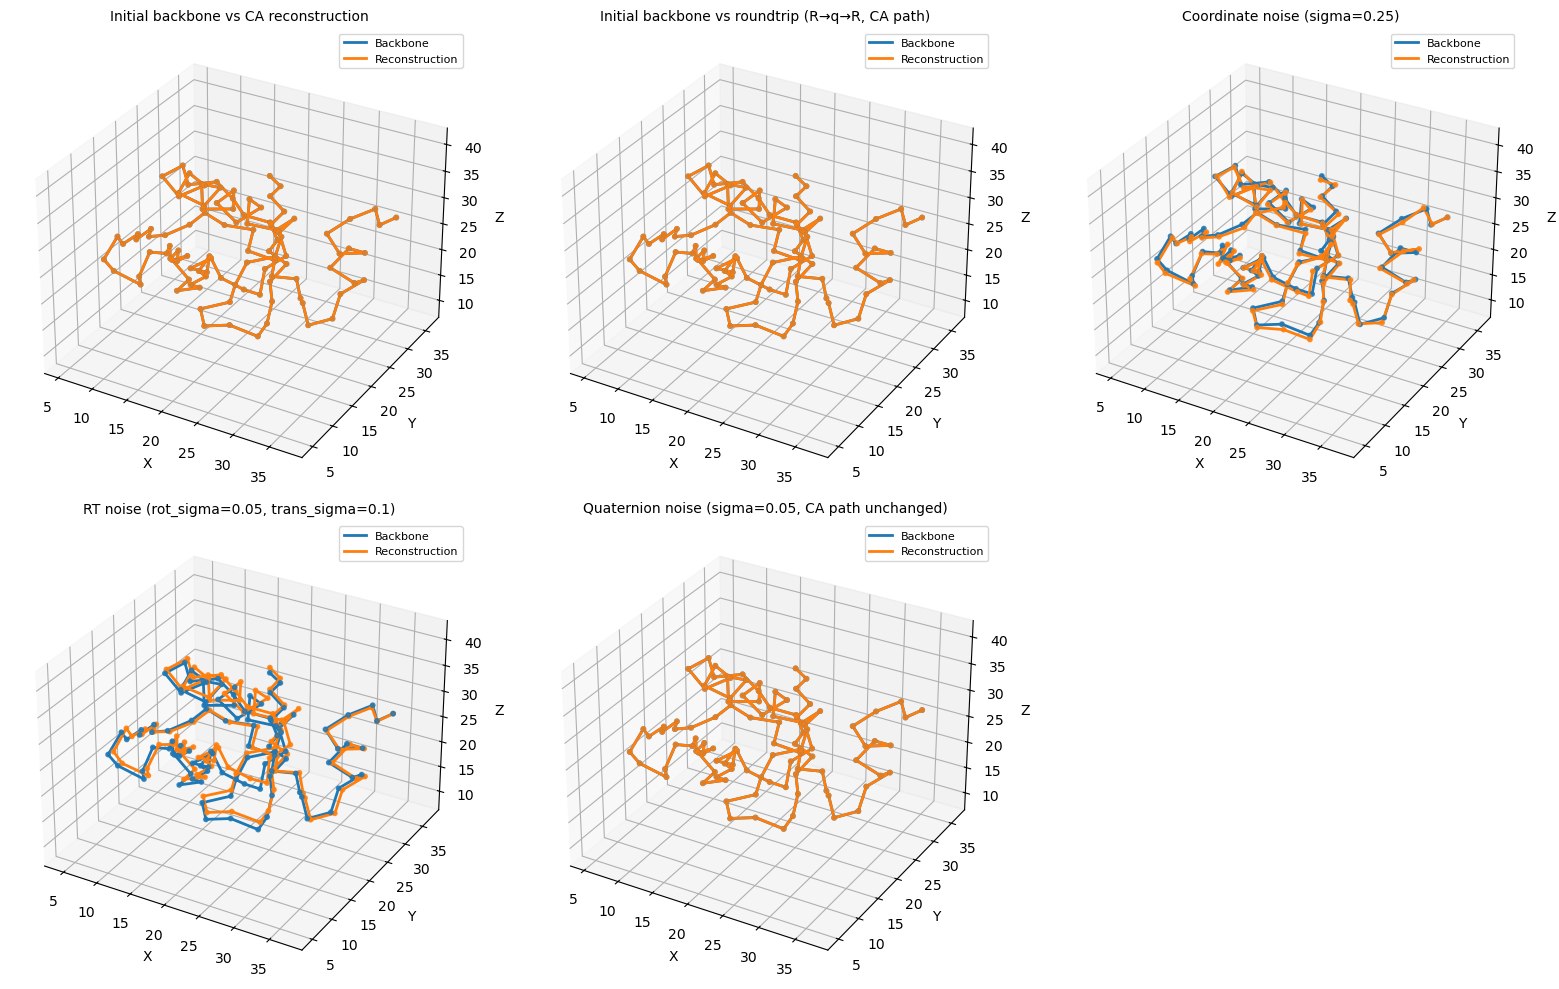

In [18]:
fig = plt.figure(figsize=(16, 10))

plots = [
    ("Initial backbone vs CA reconstruction", backbone_ca, ca_recon),
    ("Initial backbone vs roundtrip (R→q→R, CA path)", backbone_ca, ca_recon),
    (f"Coordinate noise (sigma={coord_noise})", backbone_ca, coord_noisy_positions),
    (f"RT noise (rot_sigma={rot_noise_rad}, trans_sigma={trans_noise})", backbone_ca, rt_noisy_positions),
    (f"Quaternion noise (sigma={quat_noise}, CA path unchanged)", backbone_ca, quat_noisy_positions),
]

for i, (title, ref_coords, pred_coords) in enumerate(plots, start=1):
    ax = fig.add_subplot(2, 3, i, projection="3d")
    _plot_two_chains(ax, ref_coords, pred_coords, title)
    _set_equal_axes(ax, [ref_coords, pred_coords])

# Leave the 6th panel empty for cleaner layout
ax_empty = fig.add_subplot(2, 3, 6)
ax_empty.axis("off")

plt.tight_layout()
plt.show()

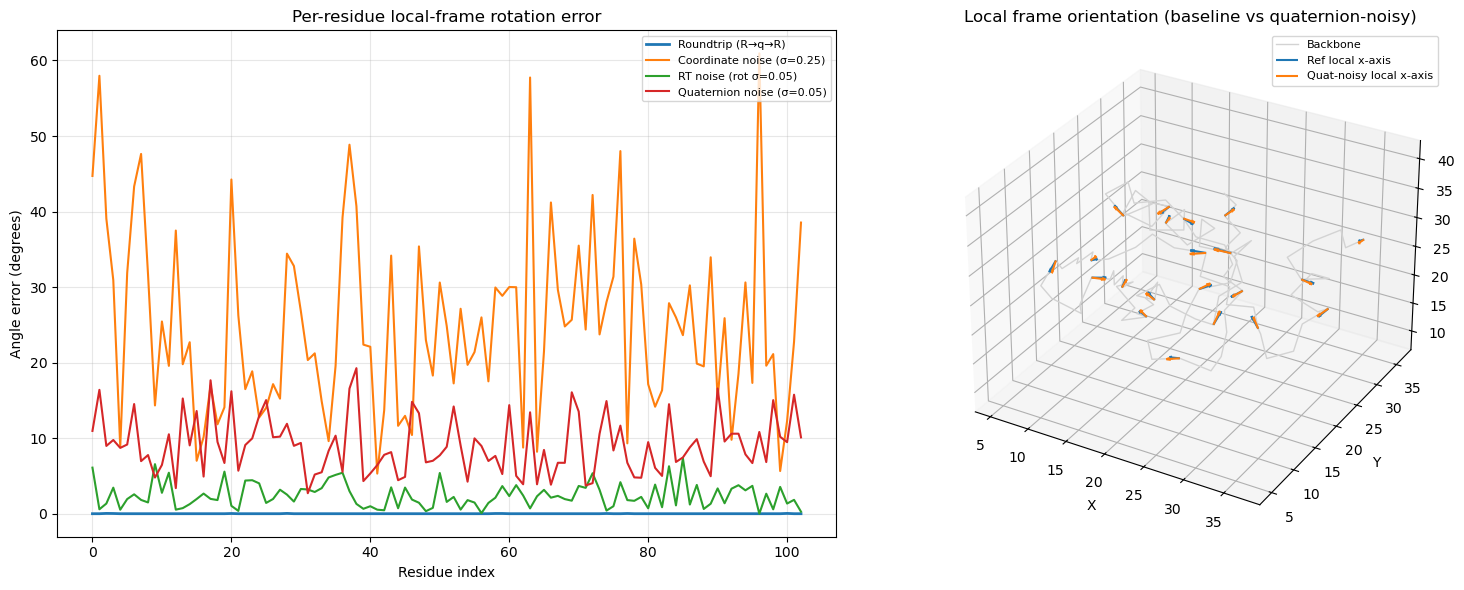

Mean rotation error (deg):
  Roundtrip:         0.002782
  Coordinate noise:  25.000710
  RT noise:          2.418117
  Quaternion noise:  9.122670


: 

In [ ]:
# Orientation-focused visualization (shows quaternion noise effect explicitly)

def rotation_angle_deg(R_ref: torch.Tensor, R_other: torch.Tensor) -> torch.Tensor:
    """Per-residue angular difference between two rotation matrices in degrees."""
    r_rel = torch.matmul(R_ref.transpose(-1, -2), R_other)
    tr = r_rel[..., 0, 0] + r_rel[..., 1, 1] + r_rel[..., 2, 2]
    cos_theta = torch.clamp((tr - 1.0) * 0.5, -1.0, 1.0)
    return torch.rad2deg(torch.acos(cos_theta))


ang_roundtrip = rotation_angle_deg(rotations, rotations_from_quat)
ang_coord = rotation_angle_deg(rotations, coord_rotations)
ang_rt = rotation_angle_deg(rotations, rt_noisy_rotations)
ang_quat = rotation_angle_deg(rotations, quat_noisy_rotations)

fig = plt.figure(figsize=(16, 6))

# Left panel: per-residue rotation error curves
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(ang_roundtrip.cpu().numpy(), label="Roundtrip (R→q→R)", linewidth=2)
ax1.plot(ang_coord.cpu().numpy(), label=f"Coordinate noise (σ={coord_noise})", linewidth=1.5)
ax1.plot(ang_rt.cpu().numpy(), label=f"RT noise (rot σ={rot_noise_rad})", linewidth=1.5)
ax1.plot(ang_quat.cpu().numpy(), label=f"Quaternion noise (σ={quat_noise})", linewidth=1.5)
ax1.set_title("Per-residue local-frame rotation error")
ax1.set_xlabel("Residue index")
ax1.set_ylabel("Angle error (degrees)")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)

# Right panel: local x-axis quiver overlay (baseline vs quaternion-noisy)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
stride = max(1, len(backbone_ca) // 20)
idx = torch.arange(0, len(backbone_ca), stride, device=backbone_ca.device)

pos = backbone_ca[idx]
x_ref = rotations[idx, :, 0]
x_quat = quat_noisy_rotations[idx, :, 0]

pos_np = pos.detach().cpu().numpy()
x_ref_np = x_ref.detach().cpu().numpy()
x_quat_np = x_quat.detach().cpu().numpy()

ax2.plot(backbone_ca[:, 0].cpu().numpy(), backbone_ca[:, 1].cpu().numpy(), backbone_ca[:, 2].cpu().numpy(), color="lightgray", linewidth=1, label="Backbone")
ax2.quiver(pos_np[:, 0], pos_np[:, 1], pos_np[:, 2], x_ref_np[:, 0], x_ref_np[:, 1], x_ref_np[:, 2], length=2.0, normalize=True, color="tab:blue", label="Ref local x-axis")
ax2.quiver(pos_np[:, 0], pos_np[:, 1], pos_np[:, 2], x_quat_np[:, 0], x_quat_np[:, 1], x_quat_np[:, 2], length=2.0, normalize=True, color="tab:orange", label="Quat-noisy local x-axis")

ax2.set_title("Local frame orientation (baseline vs quaternion-noisy)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
_set_equal_axes(ax2, [backbone_ca])
ax2.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

print("Mean rotation error (deg):")
print(f"  Roundtrip:         {ang_roundtrip.mean().item():.6f}")
print(f"  Coordinate noise:  {ang_coord.mean().item():.6f}")
print(f"  RT noise:          {ang_rt.mean().item():.6f}")
print(f"  Quaternion noise:  {ang_quat.mean().item():.6f}")